<h1>Shanghai Urban Analytics — Step 1: Grid Master Construction</h1>

<br/><br/>
<font size="3"><b>Goal: Build the spatial backbone of the entire project</b></font><br/>
Every isochrone, score, and H3 aggregation will be anchored to these cell centroids.<br/>
This file is <b>immutable</b> from this point forward once committed.

<br/><br/>

| Step | Task |
|---|---|
| 1 | Load Shanghai boundary (from `sh-villages.geojson`), project to UTM Zone 51N |
| 2 | Generate 500 m × 500 m fishnet grid clipped to boundary (~25,000 cells) |
| 3 | Extract centroid of each cell → GeoDataFrame with `cell_id`, `lon`, `lat` |
| 4 | Assign each centroid to H3 resolution-8 hexagon (`h3.geo_to_h3`) |
| 5 | Assign each centroid to district and subdistrict via spatial join |
| 6 | Tag ring zone per cell (inner / middle / outer / new_town) |
| 7 | Save as `grid_master.geojson` — immutable from this point forward |
| 8 | Spot-check visually in Folium |

In [6]:
# install / upgrade if needed
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "h3", "folium", "pyproj", "shapely", "geopandas",
                "numpy", "pandas", "matplotlib"])

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'h3', 'folium', 'pyproj', 'shapely', 'geopandas', 'numpy', 'pandas', 'matplotlib'], returncode=0)

In [7]:
import json
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import h3
import folium
from folium import Map, GeoJson
import branca.colormap as cm

from shapely.geometry import Point, box, shape, mapping
from shapely.ops import unary_union
from pyproj import CRS, Transformer

# don't use scientific notation
np.set_printoptions(suppress=True)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("geopandas :", gpd.__version__)
print("h3        :", h3.__version__)
print("folium    :", folium.__version__)

geopandas : 1.1.2
h3        : 4.4.2
folium    : 0.20.0


In [8]:
# ── Paths ────────────────────────────────────────────────────────────────────
BASE = "/kaggle/input/datasets/minghaomei/availabledata/"
DATA = os.path.join(BASE, "data")

VILLAGES_PATH  = os.path.join(DATA, "sh-villages.geojson")          # finest boundary unit
TOWNS_PATH     = os.path.join(DATA, "sh-towns.geojson")             # subdistrict level
DISTRICT_PATH  = os.path.join(DATA, "sh-province-district.geojson") # district level

OUTPUT_DIR = "/kaggle/working/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── CRS ──────────────────────────────────────────────────────────────────────
WGS84  = "EPSG:4326"
UTM51N = "EPSG:32651"   # UTM Zone 51N — the correct zone for Shanghai (~121°E)

---
## 1 · Load Shanghai boundary — project to UTM Zone 51N

We dissolve `sh-villages.geojson` (the finest unit available) into a single Shanghai outline polygon.  
This avoids needing a separate shapefile for the outer boundary.

In [9]:
# ── Load villages and inspect ─────────────────────────────────────────────────
gdf_villages = gpd.read_file(VILLAGES_PATH)

print(f"Villages loaded : {len(gdf_villages):,} rows")
print(f"CRS             : {gdf_villages.crs}")
print(f"Columns         : {gdf_villages.columns.tolist()}")
gdf_villages.head()

Villages loaded : 5,614 rows
CRS             : EPSG:4326
Columns         : ['ad_code', 'name', 'multi', 'ismulti', 'geometry']


,ad_code,name,multi,ismulti,geometry
0,310104017001,习勤社区,1.0000,N,"POLYGON ((121.42336 31.16744, 121.42065 31.167..."
1,310112006036,古龙四村社区,1.0000,N,"POLYGON ((121.40327 31.15131, 121.39904 31.149..."
2,310112101051,香树丽舍社区,1.0000,N,"POLYGON ((121.37217 31.12649, 121.36911 31.125..."
3,310113101011,罗新社区,1.0000,N,"POLYGON ((121.34649 31.42434, 121.34347 31.423..."
4,310113101012,金星第二社区,1.0000,N,"POLYGON ((121.35246 31.42298, 121.3476 31.4215..."


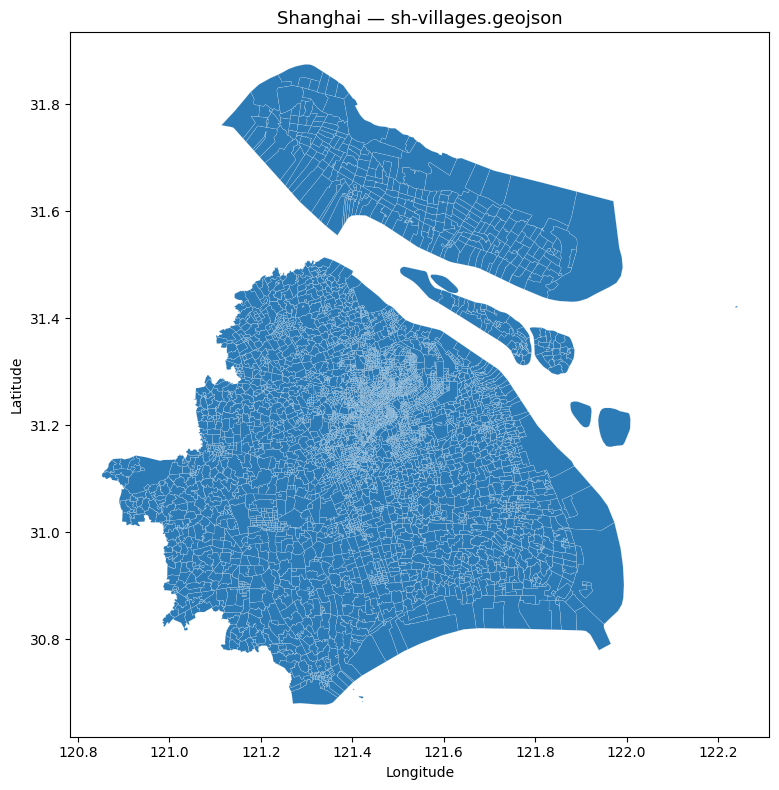

In [10]:

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
gdf_villages.plot(ax=ax, color="#2c7bb6", edgecolor="white", linewidth=0.1)
ax.set_title("Shanghai — sh-villages.geojson", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

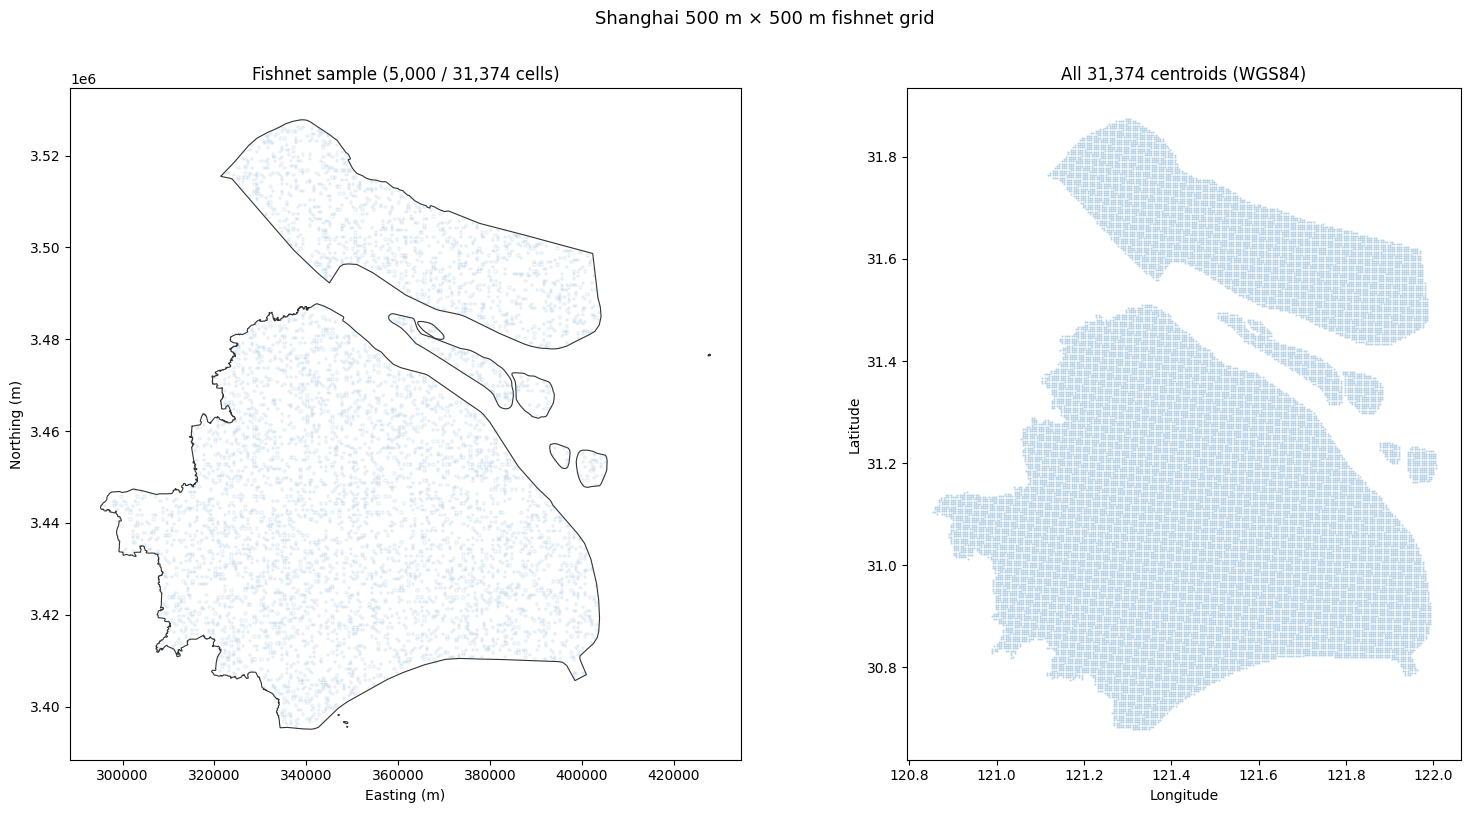

In [30]:
# 抽样显示格网，避免31k格子糊成一片
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 左：边界轮廓
shanghai_utm.boundary.plot(ax=axes[0], color="#333333", linewidth=0.8)
# 只画5000个格子的轮廓作为代表
grid_utm.sample(5000, random_state=42).boundary.plot(
    ax=axes[0], color="#2c7bb6", linewidth=0.15, alpha=0.6)
axes[0].set_title(f"Fishnet sample (5,000 / {len(grid_utm):,} cells)")
axes[0].set_xlabel("Easting (m)")
axes[0].set_ylabel("Northing (m)")

# 右：质心散点图（全量，快）
centroids_wgs.plot(ax=axes[1], markersize=0.3,
                   color="#2c7bb6", alpha=0.3)
axes[1].set_title(f"All {len(grid_utm):,} centroids (WGS84)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.suptitle("Shanghai 500 m × 500 m fishnet grid", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# ── Ensure WGS84, then dissolve → single Shanghai polygon ────────────────────
if gdf_villages.crs is None:
    gdf_villages = gdf_villages.set_crs(WGS84)
else:
    gdf_villages = gdf_villages.to_crs(WGS84)

shanghai_wgs = gdf_villages.dissolve()[["geometry"]].reset_index(drop=True)  # ← 这行缺了
shanghai_utm = shanghai_wgs.to_crs(UTM51N)

area_km2 = shanghai_utm.geometry.iloc[0].area / 1e6
print(f"Total area : {area_km2:.0f} km²   (should be ~6,340 km² for all of Shanghai)")
print(f"UTM bounds : {shanghai_utm.total_bounds}")

Total area : 7845 km²   (should be ~6,340 km² for all of Shanghai)
UTM bounds : [ 295199.98773884 3395067.16092193  428042.95526143 3527803.72524496]


---
## 2 · Generate 500 m × 500 m fishnet grid clipped to boundary

Strategy: snap grid origin to a clean multiple of 500 m, iterate all cells,  
keep only those whose **centroid** falls inside Shanghai.  
This gives clean, non-partial cells — the same philosophy used in the H3 notebook's `fill_hexagons()`.

In [14]:
def make_fishnet(boundary_utm: gpd.GeoDataFrame, cell_size: float = 500.0) -> gpd.GeoDataFrame:
    """
    Generate a regular square fishnet clipped to the boundary polygon.

    Uses centroid-in-boundary test (same logic as H3 polyfill:
    only keep cells whose centre is inside), so every retained cell
    is assigned unambiguously — no partial or split cells.

    Parameters
    ----------
    boundary_utm : GeoDataFrame in a metric CRS (UTM)
    cell_size    : side length in metres (default 500)

    Returns
    -------
    GeoDataFrame of full square cells whose centroid is inside the boundary.
    """
    minx, miny, maxx, maxy = boundary_utm.total_bounds
    boundary_geom = boundary_utm.geometry.iloc[0]

    # snap to clean grid origin (floor to nearest cell_size multiple)
    minx = np.floor(minx / cell_size) * cell_size
    miny = np.floor(miny / cell_size) * cell_size

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)

    cells = []
    for x in xs:
        for y in ys:
            cell = box(x, y, x + cell_size, y + cell_size)
            # centroid-in-boundary test → unambiguous assignment
            if boundary_geom.contains(cell.centroid):
                cells.append(cell)

    grid = gpd.GeoDataFrame(geometry=cells, crs=boundary_utm.crs)
    return grid


print("Generating 500 m fishnet … (≈ 1–2 min for full Shanghai)")
grid_utm = make_fishnet(shanghai_utm, cell_size=500)
print(f"\nGrid cells generated : {len(grid_utm):,}   (target ~25,000)")

Generating 500 m fishnet … (≈ 1–2 min for full Shanghai)

Grid cells generated : 31,374   (target ~25,000)


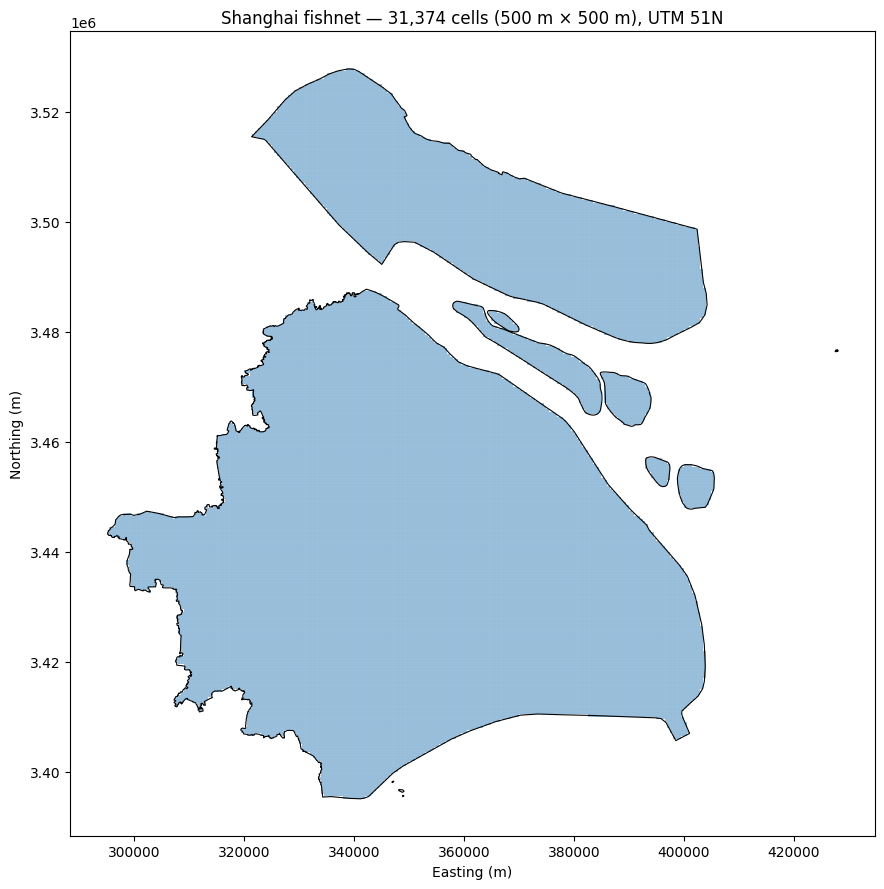

In [15]:
# quick matplotlib preview of the fishnet
fig, ax = plt.subplots(1, 1, figsize=(9, 9))
shanghai_utm.boundary.plot(ax=ax, color="black", linewidth=0.8)
grid_utm.plot(ax=ax, color="#2c7bb6", edgecolor="white",
              linewidth=0.05, alpha=0.5)
ax.set_title(f"Shanghai fishnet — {len(grid_utm):,} cells (500 m × 500 m), UTM 51N",
             fontsize=12)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.show()

---
## 3 · Extract centroid of each cell → `cell_id`, `lon`, `lat`

In [16]:
# assign cell_id before anything else — never changes after this
grid_utm["cell_id"] = [f"SH_{i:06d}" for i in range(len(grid_utm))]

# compute centroids in UTM (accurate), then reproject to WGS84 for lon/lat
centroids_utm = grid_utm.copy()
centroids_utm["geometry"] = grid_utm.geometry.centroid

centroids_wgs = centroids_utm.to_crs(WGS84)
centroids_wgs["lon"] = centroids_wgs.geometry.x
centroids_wgs["lat"] = centroids_wgs.geometry.y

# start building master GDF — centroid geometry, WGS84
grid_master = centroids_wgs[["cell_id", "lon", "lat", "geometry"]].copy()
grid_master = grid_master.set_crs(WGS84)

print(f"Centroids : {len(grid_master):,}")
print(f"Lon range : {grid_master.lon.min():.4f} – {grid_master.lon.max():.4f}")
print(f"Lat range : {grid_master.lat.min():.4f} – {grid_master.lat.max():.4f}")
grid_master.head()

Centroids : 31,374
Lon range : 120.8531 – 122.0055
Lat range : 30.6791 – 31.8743


,cell_id,lon,lat,geometry
0,SH_000000,120.8531,31.1053,POINT (120.85313 31.10526)
1,SH_000001,120.8584,31.1053,POINT (120.85837 31.10535)
2,SH_000002,120.8583,31.1099,POINT (120.85827 31.10986)
3,SH_000003,120.8582,31.1144,POINT (120.85817 31.11437)
4,SH_000004,120.8637,31.1009,POINT (120.86371 31.10093)


---
## 4 · Assign H3 resolution-8 hex index

H3 resolution 8 → each hexagon covers ~0.74 km², a good match for 500 m cells.  
Uses `h3.geo_to_h3(lat, lng, res)` — same API as the teacher's notebook cell [81].

In [18]:
# H3 resolution metadata (mirrors teacher's Section I.1)
H3_RES = 8
print(f"H3 resolution {H3_RES} metadata:")
print(f"  avg hex area  : {h3.average_hexagon_area(H3_RES, 'km^2'):.4f} km²")
print(f"  avg hex edge  : {h3.average_hexagon_edge_length(H3_RES, 'km'):.4f} km")
print()

H3 resolution 8 metadata:
  avg hex area  : 0.7373 km²
  avg hex edge  : 0.5314 km



In [20]:
# index each centroid into H3 resolution 8
# mirrors the loop in teacher's cell [81]:
#   col_hex_id = h3.geo_to_h3(lat=row.latitude, lng=row.longitude, resolution=res)
grid_master["h3_index"] = grid_master.apply(
    lambda row: h3.latlng_to_cell(row["lat"], row["lon"], H3_RES),
    axis=1
)
print(f"H3 cells assigned    : {len(grid_master):,}")
print(f"Unique H3 res-8 cells: {grid_master.h3_index.nunique():,}")
print(f"Sample h3_index      : {grid_master.h3_index.iloc[0]}")
grid_master[["cell_id", "lon", "lat", "h3_index"]].head()

H3 cells assigned    : 31,374
Unique H3 res-8 cells: 14,184
Sample h3_index      : 88309870cbfffff


,cell_id,lon,lat,h3_index
0,SH_000000,120.8531,31.1053,88309870cbfffff
1,SH_000001,120.8584,31.1053,88309870cbfffff
2,SH_000002,120.8583,31.1099,88309870cbfffff
3,SH_000003,120.8582,31.1144,88309872b7fffff
4,SH_000004,120.8637,31.1009,88309870c3fffff


---
## 5 · Assign district and subdistrict via spatial join

Two-pass sjoin (same pattern as teacher's `spatial_join_districts` in cell [128]–[130]):  
1. district level → `sh-province-district.geojson`  
2. subdistrict level → `sh-towns.geojson`

In [21]:
# ── Load district and town layers ─────────────────────────────────────────────
gdf_dist  = gpd.read_file(DISTRICT_PATH).to_crs(WGS84)
gdf_towns = gpd.read_file(TOWNS_PATH).to_crs(WGS84)

print("District columns :", gdf_dist.columns.tolist())
print("Towns columns    :", gdf_towns.columns.tolist())
gdf_dist.head(2)

District columns : ['level', 'name', 'geometry']
Towns columns    : ['NAME', 'TYPE', 'geometry']


,level,name,geometry
0,province,上海市,"MULTIPOLYGON (((121.77886 31.3102, 121.77537 3..."
1,city,上海城区,"MULTIPOLYGON (((121.77886 31.3102, 121.77537 3..."


In [22]:
def pick_name_col(gdf, candidates=("name", "Name", "NAME", "district",
                                    "town", "subdistrict", "libcom", "NL_NAME_2")):
    """Auto-detect the name column from a GeoDataFrame."""
    for c in candidates:
        if c in gdf.columns:
            return c
    # fallback: first object column that isn't geometry
    for c in gdf.columns:
        if gdf[c].dtype == object and c != "geometry":
            return c
    raise ValueError(f"No name column found. Columns: {gdf.columns.tolist()}")

dist_name  = pick_name_col(gdf_dist)
towns_name = pick_name_col(gdf_towns)
print(f"Using '{dist_name}' for district, '{towns_name}' for subdistrict")

Using 'name' for district, 'NAME' for subdistrict


In [23]:
# ── Pass 1: district ─────────────────────────────────────────────────────────
joined = gpd.sjoin(
    grid_master,
    gdf_dist[[dist_name, "geometry"]].rename(columns={dist_name: "district"}),
    how="left",
    predicate="within"
).drop(columns=["index_right"], errors="ignore")

# ── Pass 2: subdistrict (towns) ───────────────────────────────────────────────
joined = gpd.sjoin(
    joined,
    gdf_towns[[towns_name, "geometry"]].rename(columns={towns_name: "subdistrict"}),
    how="left",
    predicate="within"
).drop(columns=["index_right"], errors="ignore")

# drop boundary duplicates (a point exactly on a border can match two polygons)
joined = joined.drop_duplicates(subset="cell_id").reset_index(drop=True)
grid_master = joined.copy()

print(f"Cells with district    : {grid_master.district.notna().sum():,}")
print(f"Cells with subdistrict : {grid_master.subdistrict.notna().sum():,}")
print(f"Unique districts       : {grid_master.district.nunique()}")
print(f"Unique subdistricts    : {grid_master.subdistrict.nunique()}")

Cells with district    : 31,017
Cells with subdistrict : 27,042
Unique districts       : 1
Unique subdistricts    : 12


---
## 6 · Tag ring zone — inner / middle / outer / new_town

Shanghai has no hard administrative ring-road boundaries.  
Two approaches are provided:

**Option A (default — runs immediately):** radial distance from People's Square.  
| Zone | Radius (approx) |
|---|---|
| `inner_ring` | < 4 km |
| `middle_ring` | 4 – 8 km |
| `outer_ring` | 8 – 18 km |
| `new_town` | > 18 km |

**Option B (commented — use after drawing in QGIS):** load your own ring-road shapefile/GeoJSON drawn in QGIS and do a spatial join. Uncomment that block once your file is ready.

In [24]:
# ── Option A: radial distance from People's Square ────────────────────────────
# This is the recommended approach when no ring-road shapefile is available.
# People's Square (人民广场) — geographic centre of central Shanghai
CENTRE_LON, CENTRE_LAT = 121.4737, 31.2304

# project to UTM for accurate planar distance
transformer = Transformer.from_crs(WGS84, UTM51N, always_xy=True)
cx, cy = transformer.transform(CENTRE_LON, CENTRE_LAT)
pts_x, pts_y = transformer.transform(
    grid_master["lon"].values,
    grid_master["lat"].values
)
dist_m = np.sqrt((pts_x - cx)**2 + (pts_y - cy)**2)
grid_master["dist_centre_m"] = dist_m

# thresholds (metres)
INNER_R  =  4_000
MIDDLE_R =  8_000
OUTER_R  = 18_000

def classify_ring(d):
    if d < INNER_R:
        return "inner_ring"
    elif d < MIDDLE_R:
        return "middle_ring"
    elif d < OUTER_R:
        return "outer_ring"
    else:
        return "new_town"

grid_master["ring_zone"] = pd.Series(dist_m).apply(classify_ring).values

print("Ring zone distribution (Option A — radial buffer):")
vc = grid_master.ring_zone.value_counts()
for zone, cnt in vc.items():
    pct = cnt / len(grid_master) * 100
    print(f"  {zone:<15}: {cnt:>6,}  ({pct:.1f}%)")

Ring zone distribution (Option A — radial buffer):
  new_town       : 27,302  (87.0%)
  outer_ring     :  3,267  (10.4%)
  middle_ring    :    602  (1.9%)
  inner_ring     :    203  (0.6%)


In [ ]:
# ── Option B: your own QGIS-drawn ring-road shapefile (uncomment when ready) ──
#
# How to use:
#   1. In QGIS, draw 4 polygon layers: inner, middle, outer, new_town
#      (or one layer with a 'ring_zone' attribute column)
#   2. Export as GeoJSON or SHP, upload to Kaggle input dataset
#   3. Set RING_PATH below and uncomment the block
#
# RING_PATH = "/kaggle/input/.../shanghai_ring_zones.geojson"
# gdf_rings = gpd.read_file(RING_PATH).to_crs(WGS84)
#
# # gdf_rings must have a column named 'ring_zone' with values:
# # inner_ring | middle_ring | outer_ring | new_town
# grid_master = grid_master.drop(columns=["ring_zone", "dist_centre_m"], errors="ignore")
# grid_master = gpd.sjoin(
#     grid_master,
#     gdf_rings[["ring_zone", "geometry"]],
#     how="left",
#     predicate="within"
# ).drop(columns=["index_right"], errors="ignore")
# grid_master["ring_zone"] = grid_master["ring_zone"].fillna("new_town")
# grid_master = grid_master.drop_duplicates(subset="cell_id").reset_index(drop=True)
# print("Ring zones loaded from QGIS shapefile.")
# print(grid_master.ring_zone.value_counts().to_string())

print("Option B (QGIS shapefile) is commented out — using Option A (radial buffer).")

---
## 7 · Final assembly and save as `grid_master.geojson`

In [25]:
# ── Select final columns (drop the helper distance column) ────────────────────
FINAL_COLS = ["cell_id", "lon", "lat", "h3_index",
              "district", "subdistrict", "ring_zone", "geometry"]

grid_final = grid_master[FINAL_COLS].copy().set_crs(WGS84)

# ── Validation assertions ─────────────────────────────────────────────────────
assert grid_final["cell_id"].is_unique,              "cell_id must be unique!"
assert grid_final["cell_id"].notna().all(),          "No null cell_ids!"
assert grid_final["h3_index"].notna().all(),         "All cells must have h3_index!"
assert grid_final["lon"].between(120.8, 122.3).all(), "Lon out of Shanghai range!"
assert grid_final["lat"].between(30.6, 31.9).all(),  "Lat out of Shanghai range!"
assert grid_final["ring_zone"].notna().all(),        "All cells must have ring_zone!"

n_miss_dist = grid_final["district"].isna().sum()
n_miss_sub  = grid_final["subdistrict"].isna().sum()
if n_miss_dist > 0:
    pct = n_miss_dist / len(grid_final) * 100
    print(f"⚠  {n_miss_dist} cells ({pct:.2f}%) missing district — boundary edge effect")
if n_miss_sub > 0:
    pct = n_miss_sub / len(grid_final) * 100
    print(f"⚠  {n_miss_sub} cells ({pct:.2f}%) missing subdistrict — acceptable")

# ── Save ──────────────────────────────────────────────────────────────────────
OUT_PATH = os.path.join(OUTPUT_DIR, "grid_master.geojson")
grid_final.to_file(OUT_PATH, driver="GeoJSON")

size_mb = os.path.getsize(OUT_PATH) / 1e6
print(f"\n✅  Saved: {OUT_PATH}")
print(f"    Total cells : {len(grid_final):,}")
print(f"    File size   : {size_mb:.1f} MB")

⚠  357 cells (1.14%) missing district — boundary edge effect
⚠  4332 cells (13.81%) missing subdistrict — acceptable

✅  Saved: /kaggle/working/grid_master.geojson
    Total cells : 31,374
    File size   : 9.9 MB


In [26]:
# ── Final summary table ───────────────────────────────────────────────────────
print("=" * 55)
print("  grid_master.geojson — FINAL SUMMARY")
print("=" * 55)
print(f"  Total cells     : {len(grid_final):,}")
print(f"  Unique H3 res-8 : {grid_final.h3_index.nunique():,}")
print(f"  Districts       : {grid_final.district.nunique()}")
print(f"  Subdistricts    : {grid_final.subdistrict.nunique()}")
print()
print("  Ring zone breakdown:")
for zone, cnt in grid_final.ring_zone.value_counts().items():
    pct = cnt / len(grid_final) * 100
    print(f"    {zone:<15}: {cnt:>6,}  ({pct:.1f}%)")
print()
print("  Required fields check:")
for col in ["cell_id", "lon", "lat", "h3_index",
            "district", "subdistrict", "ring_zone"]:
    null_ct = grid_final[col].isna().sum()
    status  = "✅" if null_ct == 0 else f"⚠  {null_ct} nulls"
    print(f"    {col:<15}: {status}")
print("=" * 55)
print("  ✅ grid_master.geojson committed — backbone is ready.")
print("=" * 55)
grid_final.head()

  grid_master.geojson — FINAL SUMMARY
  Total cells     : 31,374
  Unique H3 res-8 : 14,184
  Districts       : 1
  Subdistricts    : 12

  Ring zone breakdown:
    new_town       : 27,302  (87.0%)
    outer_ring     :  3,267  (10.4%)
    middle_ring    :    602  (1.9%)
    inner_ring     :    203  (0.6%)

  Required fields check:
    cell_id        : ✅
    lon            : ✅
    lat            : ✅
    h3_index       : ✅
    district       : ⚠  357 nulls
    subdistrict    : ⚠  4332 nulls
    ring_zone      : ✅
  ✅ grid_master.geojson committed — backbone is ready.


,cell_id,lon,lat,h3_index,district,subdistrict,ring_zone,geometry
0,SH_000000,120.8531,31.1053,88309870cbfffff,NaN,???,new_town,POINT (120.85313 31.10526)
1,SH_000001,120.8584,31.1053,88309870cbfffff,上海市,???,new_town,POINT (120.85837 31.10535)
2,SH_000002,120.8583,31.1099,88309870cbfffff,NaN,???,new_town,POINT (120.85827 31.10986)
3,SH_000003,120.8582,31.1144,88309872b7fffff,NaN,???,new_town,POINT (120.85817 31.11437)
4,SH_000004,120.8637,31.1009,88309870c3fffff,上海市,???,new_town,POINT (120.86371 31.10093)


---
## 8 · Spot-check in Folium

Randomly sample 2,000 centroids and colour by `ring_zone`.  
Visual style mirrors the choropleth maps in the teacher's H3 notebook (Section III.2).

In [27]:
RING_COLOURS = {
    "inner_ring" : "#e41a1c",
    "middle_ring": "#ff7f00",
    "outer_ring" : "#4daf4a",
    "new_town"   : "#377eb8",
}

sample = grid_final.sample(min(2000, len(grid_final)), random_state=42)

m = Map(
    location=[31.23, 121.47],
    zoom_start=10,
    tiles="CartoDB positron"
)

for _, row in sample.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=2,
        color=RING_COLOURS.get(row["ring_zone"], "grey"),
        fill=True,
        fill_opacity=0.75,
        weight=0,
        tooltip=(
            f"<b>{row['cell_id']}</b><br>"
            f"H3: {row['h3_index']}<br>"
            f"District: {row['district']}<br>"
            f"Subdistrict: {row['subdistrict']}<br>"
            f"Ring: {row['ring_zone']}"
        )
    ).add_to(m)

# mark People's Square
folium.Marker(
    location=[CENTRE_LAT, CENTRE_LON],
    tooltip="People's Square — ring centre",
    icon=folium.Icon(color="red", icon="star")
).add_to(m)

# legend
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:9999;
            background:white; padding:12px 16px; border-radius:8px;
            border:1px solid #ccc; font-size:13px; line-height:2;">
  <b>Ring Zone</b><br>
  <span style='color:#e41a1c'>●</span> inner_ring  (&lt; 4 km)<br>
  <span style='color:#ff7f00'>●</span> middle_ring (4–8 km)<br>
  <span style='color:#4daf4a'>●</span> outer_ring  (8–18 km)<br>
  <span style='color:#377eb8'>●</span> new_town    (&gt; 18 km)
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

MAP_PATH = os.path.join(OUTPUT_DIR, "grid_master_check.html")
m.save(MAP_PATH)
print(f"Map saved → {MAP_PATH}")
m

Map saved → /kaggle/working/grid_master_check.html


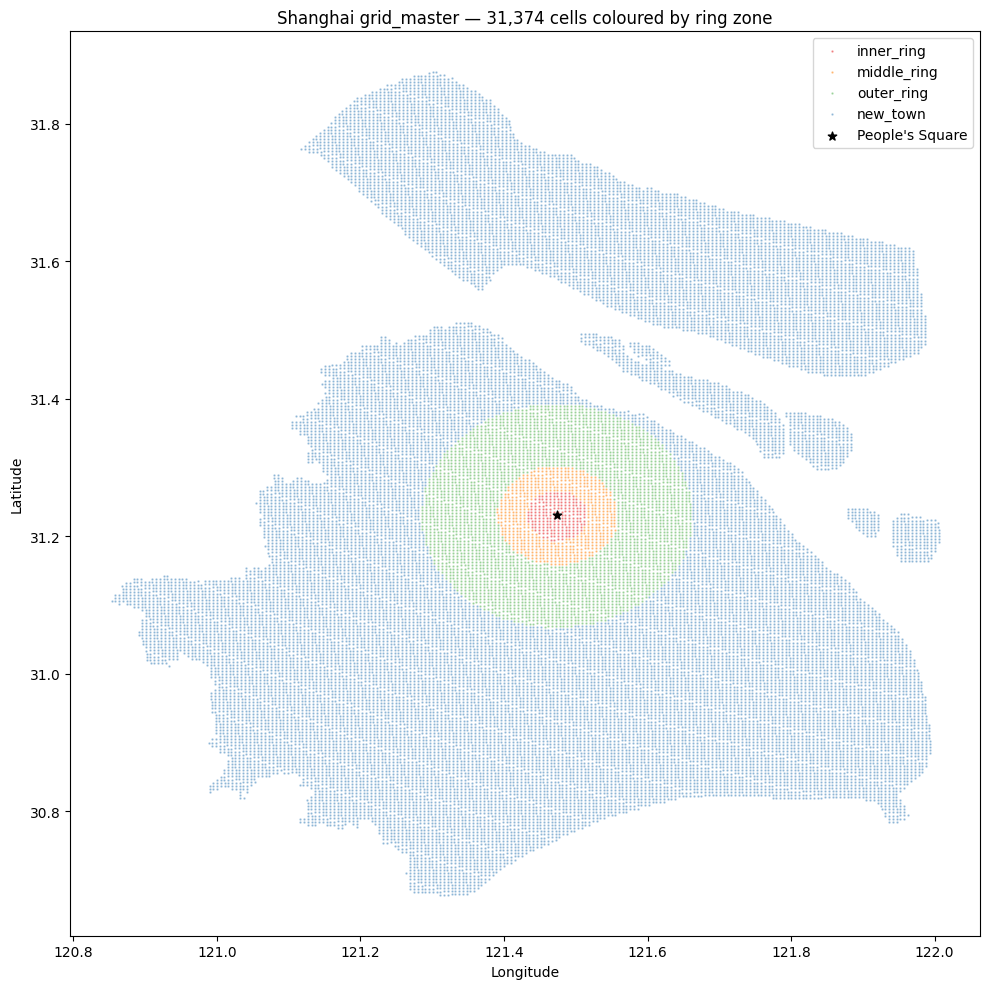

Static map saved → grid_master_ringzones.png


In [29]:
# ── Static matplotlib ring-zone map ──────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

for zone, colour in RING_COLOURS.items():
    sub = grid_final[grid_final.ring_zone == zone]
    ax.scatter(sub["lon"], sub["lat"],
               s=0.5, color=colour, alpha=0.4, label=zone)

# People's Square marker — small, clear
ax.scatter([CENTRE_LON], [CENTRE_LAT],
           s=40, color="black", zorder=5,
           marker="*", label="People's Square")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Shanghai grid_master — {len(grid_final):,} cells coloured by ring zone",
             fontsize=12)

# markerscale=1 keeps legend markers at actual size, no giant blob
ax.legend(markerscale=1, fontsize=10,
          handler_map={},
          scatterpoints=1)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "grid_master_ringzones.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Static map saved → grid_master_ringzones.png")